# Retirement Planning Tool

### A Python tool that projects whether a client's retirement savings will last, and analyzes how exposed that outcome is to its underlying assumptions. It combines a year-by-year projection engine with sensitivity analysis and a Monte Carlo simulation to express plan outcomes as a probability of success. 

Built on hypothetical client profiles — no real client data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

print("ready")

ready


## 1. Client Personas

In [2]:
personas = {
    "young_saver": {
        "current_age": 28,
        "retirement_age": 65,
        "end_age": 95,
        "current_savings": 40_000,
        "annual_contribution": 12_000,
        "annual_spending_retirement": 60_000,
        "expected_return": 0.07,
        "inflation": 0.025,
        "ss_income": 30_000,
        "ss_start_age": 67,
    },
    "mid_career": {
        "current_age": 45,
        "retirement_age": 65,
        "end_age": 95,
        "current_savings": 300_000,
        "annual_contribution": 25_000,
        "annual_spending_retirement": 90_000,
        "expected_return": 0.07,
        "inflation": 0.025,
        "ss_income": 36_000,
        "ss_start_age": 67,
    },
    "near_retiree": {
        "current_age": 58,
        "retirement_age": 67,
        "end_age": 95,
        "current_savings": 400_000,
        "annual_contribution": 20_000,
        "annual_spending_retirement": 75_000,
        "expected_return": 0.07,
        "inflation": 0.025,
        "ss_income": 30_000,
        "ss_start_age": 67,
    },
}

## 2. Core Projection Engine

In [3]:
def project(persona):
    # pull the values out of the persona dictionary
    balance = persona["current_savings"]
    current_age = persona["current_age"]
    retirement_age = persona["retirement_age"]
    end_age = persona["end_age"]
    contribution = persona["annual_contribution"]
    base_spending = persona["annual_spending_retirement"]
    r = persona["expected_return"]
    inflation = persona["inflation"]
    ss_income = persona["ss_income"]
    ss_start_age = persona["ss_start_age"]

    records = []  # collect one row per year

    for age in range(current_age, end_age + 1):
        balance = balance * (1 + r)

        if age < retirement_age:
            balance = balance + contribution
        else:
            spending_this_year = base_spending * (1 + inflation) ** (age - retirement_age)
            if age >= ss_start_age:
                ss_this_year = ss_income * (1 + inflation) ** (age - ss_start_age)
            else:
                ss_this_year = 0
            balance = balance - (spending_this_year - ss_this_year)

        if balance < 0:
            balance = 0

        records.append({"age": age, "balance": balance})

    return pd.DataFrame(records)

In [4]:
project(personas["mid_career"])

,age,balance
0,45,3.460000e+05
1,46,3.952200e+05
2,47,4.478854e+05
3,48,5.042374e+05
4,49,5.645340e+05
5,50,6.290514e+05
6,51,6.980850e+05
7,52,7.719509e+05
8,53,8.509875e+05
9,54,9.355566e+05


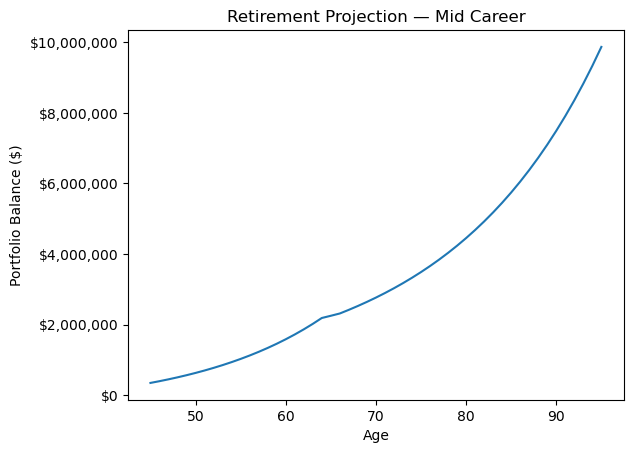

In [5]:
df = project(personas["mid_career"])

plt.plot(df["age"], df["balance"])
plt.xlabel("Age")
plt.ylabel("Portfolio Balance ($)")
plt.title("Retirement Projection — Mid Career")
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.show()

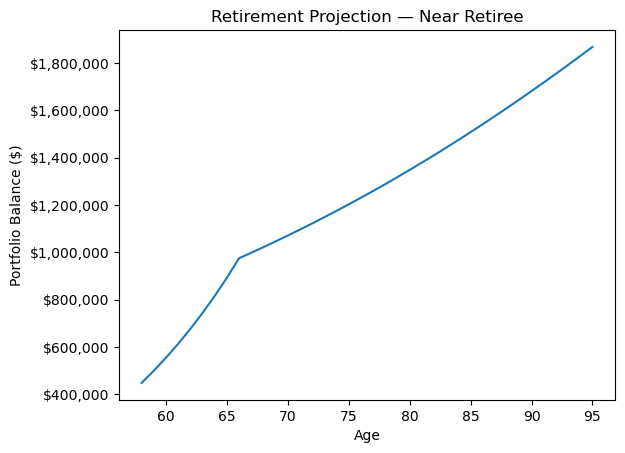

In [6]:
df = project(personas["near_retiree"])

plt.plot(df["age"], df["balance"])
plt.xlabel("Age")
plt.ylabel("Portfolio Balance ($)")
plt.title("Retirement Projection — Near Retiree")
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.show()

#### **Takeaway:** With Social Security included, the near-retiree's plan sustains through age 95 and ends near $1.9M. Strip Social Security out and the same plan depletes at 87, which isolates how much of this outcome rests on that single income source rather than on the portfolio.

In [7]:
def plan_succeeds(persona):
    df = project(persona)
    final_balance = df["balance"].iloc[-1]
    return final_balance > 0

In [8]:
def depletion_age(persona):
    df = project(persona)
    zeros = df[df["balance"] <= 0]
    if len(zeros) == 0:
        return None
    return int(zeros["age"].iloc[0])

In [9]:
print("Mid career depletes at:", depletion_age(personas["mid_career"]))
print("Near retiree depletes at:", depletion_age(personas["near_retiree"]))

Mid career depletes at: None
Near retiree depletes at: None


In [10]:
print(plan_succeeds(personas["mid_career"]))
print(plan_succeeds(personas["near_retiree"]))

True
True


## 3. Sensitivity Analysis

In [11]:
def final_balance(persona):
    df = project(persona)
    return df["balance"].iloc[-1]

In [12]:
for test_age in range(67, 73):
    test_persona = personas["near_retiree"].copy()
    test_persona["retirement_age"] = test_age
    print(f"Retire at {test_age}: ${final_balance(test_persona):,.0f}")

Retire at 67: $1,868,149
Retire at 68: $2,494,171
Retire at 69: $3,071,165
Retire at 70: $3,602,617
Retire at 71: $4,091,776
Retire at 72: $4,541,667


### Expected Return Sensitivity

In [13]:
for test_return in [0.05, 0.06, 0.07, 0.08, 0.09]:
    test_persona = personas["near_retiree"].copy()
    test_persona["expected_return"] = test_return
    result = final_balance(test_persona)
    print(f"Return {test_return:.0%}: ${result:,.0f}")

Return 5%: $0
Return 6%: $571,586
Return 7%: $1,868,149
Return 8%: $3,828,219
Return 9%: $6,734,409


#### **Takeaway:** The plan breaks even somewhere between a 5% and 6% expected return, and fails outright at 5%. Delaying retirement adds between 626k and 450k of terminal balance per year of extra work, with each additional year worth less than the one before it. Both levers matter, but the return assumption is doing more of the work, and it is the one the client controls least.

## 4. Tornado Chart

### Expected Return

In [14]:
low = personas["near_retiree"].copy()
low["expected_return"] = 0.05

high = personas["near_retiree"].copy()
high["expected_return"] = 0.09

swing_return = final_balance(high) - final_balance(low)
print(swing_return)

6734409.005451731


### Retirement Age

In [15]:
low = personas["near_retiree"].copy()
low["retirement_age"] = 65

high = personas["near_retiree"].copy()
high["retirement_age"] = 69

swing_retirement = final_balance(high) - final_balance(low)
print(swing_retirement)

3042973.640701937


### Spending

In [16]:
low = personas["near_retiree"].copy()
low["annual_spending_retirement"] = 65_000

high = personas["near_retiree"].copy()
high["annual_spending_retirement"] = 85_000

swing_spending = final_balance(high) - final_balance(low)
print(swing_spending)

-2252377.624440316


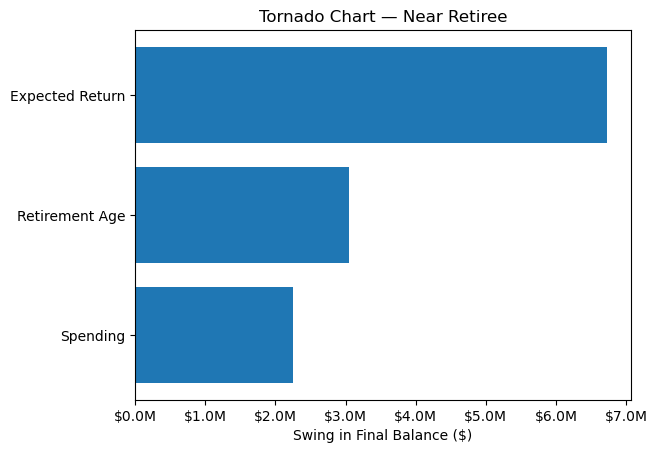

In [17]:
labels = ["Expected Return", "Retirement Age", "Spending"]
swings = [abs(swing_return), abs(swing_retirement), abs(swing_spending)]

pairs = sorted(zip(labels, swings), key=lambda p: p[1])
labels = [p[0] for p in pairs]
swings = [p[1] for p in pairs]

plt.barh(labels, swings)
plt.xlabel("Swing in Final Balance ($)")
plt.title("Tornado Chart — Near Retiree")
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
plt.show()

#### **Takeaway:** The final balance is most sensitive to investment return, followed by retirement age, then spending. This ranking depends on the ranges chosen for each variable.

## 5. Monte Carlo Simulation

In [18]:
def project_random(persona, volatility=0.15):
    balance = persona["current_savings"]
    current_age = persona["current_age"]
    retirement_age = persona["retirement_age"]
    end_age = persona["end_age"]
    contribution = persona["annual_contribution"]
    base_spending = persona["annual_spending_retirement"]
    mean_return = persona["expected_return"]
    inflation = persona["inflation"]
    ss_income = persona["ss_income"]
    ss_start_age = persona["ss_start_age"]

    records = []

    for age in range(current_age, end_age + 1):
        this_year_return = np.random.normal(mean_return, volatility)
        balance = balance * (1 + this_year_return)

        if age < retirement_age:
            balance = balance + contribution
        else:
            spending_this_year = base_spending * (1 + inflation) ** (age - retirement_age)
            if age >= ss_start_age:
                ss_this_year = ss_income * (1 + inflation) ** (age - ss_start_age)
            else:
                ss_this_year = 0
            balance = balance - (spending_this_year - ss_this_year)

        if balance < 0:
            balance = 0

        records.append({"age": age, "balance": balance})

    return pd.DataFrame(records)

In [19]:
def monte_carlo(persona, num_simulations=1000, seed=42):
    np.random.seed(seed)
    successes = 0
    for i in range(num_simulations):
        df = project_random(persona)
        final = df["balance"].iloc[-1]
        if final > 0:
            successes = successes + 1
    return successes / num_simulations

In [20]:
print(f"Probability of success: {monte_carlo(personas['near_retiree']):.0%}")

Probability of success: 56%


#### Before/after comparison

In [21]:
baseline = personas["near_retiree"]

fixed = personas["near_retiree"].copy()
fixed["retirement_age"] = 69

baseline_rate = monte_carlo(baseline)
fixed_rate = monte_carlo(fixed)

print(f"Retire at 67: {baseline_rate:.0%} probability of success")
print(f"Retire at 69: {fixed_rate:.0%} probability of success")

Retire at 67: 56% probability of success
Retire at 69: 72% probability of success


### Fan Chart

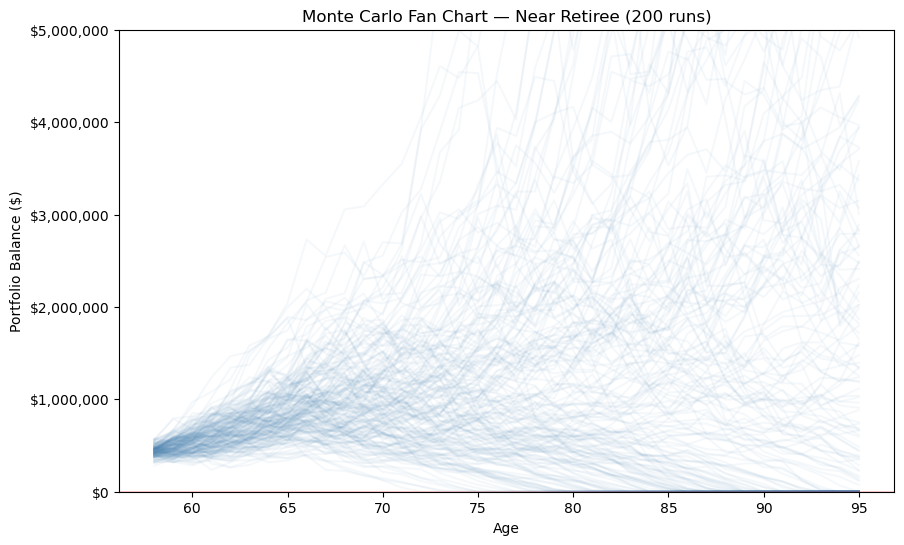

In [22]:
num_simulations = 200

plt.figure(figsize=(10, 6))

for i in range(num_simulations):
    df = project_random(personas["near_retiree"])
    plt.plot(df["age"], df["balance"], color="steelblue", alpha=0.05)

plt.axhline(0, color="red", linewidth=1)
plt.ylim(0, 5_000_000)
plt.xlabel("Age")
plt.ylabel("Portfolio Balance ($)")
plt.title("Monte Carlo Fan Chart — Near Retiree (200 runs)")
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.show()

#### **Takeaway:** Roughly 44% of simulated market paths still exhaust the portfolio before age 95, despite the deterministic projection succeeding comfortably. That gap between the single-path answer and the distribution is the case for running the simulation at all.

In [23]:
no_ss = personas["near_retiree"].copy()
no_ss["ss_income"] = 0

print(f"Without Social Security: {monte_carlo(no_ss):.0%}")
print(f"With Social Security:    {monte_carlo(personas['near_retiree']):.0%}")

Without Social Security: 22%
With Social Security:    56%


#### **Takeaway:** Social Security is worth 34 percentage points of plan success to this client, moving her from 22% to 56%. No change she could make to the portfolio comes close to that. The portfolio is only one of the client's income sources, so leaving Social Security out overstates how much work the account has to do.